# MedStock-AU: Pharmaceutical Demand Forecasting
## Module 1 — Synthetic Data Generation

**Project:** AI-Powered Pharmaceutical Demand Forecasting and Inventory Optimisation System for Australian Hospital Pharmacies  

---

### Overview

This notebook generates a realistic synthetic dataset simulating daily pharmaceutical demand across Sydney metropolitan hospital pharmacies and retail pharmacy chains.

The dataset reflects real-world patterns including:
- **Seasonal trends** — higher demand for respiratory medications in Australian winter (June–August)
- **Weekly cycles** — lower dispensing on weekends at hospital pharmacies
- **Location-based variation** — large hospitals have significantly higher demand than community pharmacies
- **Outbreak anomalies** — sudden demand spikes simulating disease outbreaks
- **Stockout events** — recorded zeros due to supply disruption

### Why Synthetic Data?

Real hospital pharmacy data is subject to strict privacy regulations in Australia (Privacy Act 1988, My Health Records Act 2012). Synthetic data allows us to simulate realistic operational conditions while maintaining full compliance.

### Data Scope

| Parameter | Value |
|-----------|-------|
| Time Period | January 2022 – December 2024 (3 years) |
| Frequency | Daily |
| Medications | 15 |
| Locations | 8 (4 hospital pharmacies + 4 retail chains) |
| Total Records | ~131,400 |
| Region | Sydney, NSW, Australia |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Libraries loaded successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

Libraries loaded successfully.
Pandas version: 2.2.2
NumPy version:  1.26.4


## 2. Define Locations

We simulate 4 major Sydney hospital pharmacies and 4 retail pharmacy chain branches.  
Each location has a `demand_multiplier` reflecting its size and patient volume.

In [4]:
locations = {
    # Hospital Pharmacies
    'RPA Hospital Pharmacy': {
        'type': 'hospital',
        'suburb': 'Camperdown',
        'demand_multiplier': 1.5,
        'beds': 700
    },
    'Westmead Hospital Pharmacy': {
        'type': 'hospital',
        'suburb': 'Westmead',
        'demand_multiplier': 1.4,
        'beds': 670
    },
    "St Vincent's Hospital Pharmacy": {
        'type': 'hospital',
        'suburb': 'Darlinghurst',
        'demand_multiplier': 1.0,
        'beds': 380
    },
    'Prince of Wales Hospital Pharmacy': {
        'type': 'hospital',
        'suburb': 'Randwick',
        'demand_multiplier': 0.9,
        'beds': 340
    },

    # Retail Pharmacy Chains
    'Chemist Warehouse Epping': {
        'type': 'retail',
        'suburb': 'Epping',
        'demand_multiplier': 0.6,
        'beds': None
    },
    'Chemist Warehouse Sydney CBD': {
        'type': 'retail',
        'suburb': 'Sydney CBD',
        'demand_multiplier': 0.8,
        'beds': None
    },
    'Priceline Pharmacy Pitt Street': {
        'type': 'retail',
        'suburb': 'Sydney CBD',
        'demand_multiplier': 0.5,
        'beds': None
    },
    'TerryWhite Chemmart Parramatta': {
        'type': 'retail',
        'suburb': 'Parramatta',
        'demand_multiplier': 0.55,
        'beds': None
    },
}

print(f"Total locations: {len(locations)}")
print(f"  Hospital pharmacies: {sum(1 for v in locations.values() if v['type'] == 'hospital')}")
print(f"  Retail pharmacies:   {sum(1 for v in locations.values() if v['type'] == 'retail')}")
print()
for name, info in locations.items():
    print(f"  {name:<40} | {info['type']:<8} | multiplier: {info['demand_multiplier']}")

Total locations: 8
  Hospital pharmacies: 4
  Retail pharmacies:   4

  RPA Hospital Pharmacy                    | hospital | multiplier: 1.5
  Westmead Hospital Pharmacy               | hospital | multiplier: 1.4
  St Vincent's Hospital Pharmacy           | hospital | multiplier: 1.0
  Prince of Wales Hospital Pharmacy        | hospital | multiplier: 0.9
  Chemist Warehouse Epping                 | retail   | multiplier: 0.6
  Chemist Warehouse Sydney CBD             | retail   | multiplier: 0.8
  Priceline Pharmacy Pitt Street           | retail   | multiplier: 0.5
  TerryWhite Chemmart Parramatta           | retail   | multiplier: 0.55


## 3. Define Medications

15 medications commonly dispensed in Australian hospital and retail pharmacies,  
based on PBS (Pharmaceutical Benefits Scheme) utilisation data.

In [5]:
medications = {
    # Both hospital and retail
    'Paracetamol':    {'base_demand': 150, 'category': 'Analgesic',        'seasonal': 'winter',  'setting': 'both'},
    'Ibuprofen':      {'base_demand': 110, 'category': 'Analgesic',        'seasonal': 'winter',  'setting': 'both'},
    'Amoxicillin':    {'base_demand': 80,  'category': 'Antibiotic',       'seasonal': 'winter',  'setting': 'both'},
    'Metformin':      {'base_demand': 120, 'category': 'Antidiabetic',     'seasonal': 'none',    'setting': 'both'},
    'Atorvastatin':   {'base_demand': 100, 'category': 'Cardiovascular',   'seasonal': 'none',    'setting': 'both'},
    'Omeprazole':     {'base_demand': 90,  'category': 'Gastrointestinal', 'seasonal': 'none',    'setting': 'both'},
    'Salbutamol':     {'base_demand': 60,  'category': 'Respiratory',      'seasonal': 'winter',  'setting': 'both'},
    'Pantoprazole':   {'base_demand': 75,  'category': 'Gastrointestinal', 'seasonal': 'none',    'setting': 'both'},
    'Codeine':        {'base_demand': 55,  'category': 'Analgesic',        'seasonal': 'winter',  'setting': 'both'},

    # Hospital-primary
    'Ondansetron':    {'base_demand': 50,  'category': 'Antiemetic',       'seasonal': 'summer',  'setting': 'hospital'},
    'Enoxaparin':     {'base_demand': 40,  'category': 'Anticoagulant',    'seasonal': 'none',    'setting': 'hospital'},
    'Dexamethasone':  {'base_demand': 35,  'category': 'Corticosteroid',   'seasonal': 'none',    'setting': 'hospital'},

    # Retail-primary
    'Sertraline':     {'base_demand': 65,  'category': 'Antidepressant',   'seasonal': 'none',    'setting': 'retail'},
    'Rosuvastatin':   {'base_demand': 85,  'category': 'Cardiovascular',   'seasonal': 'none',    'setting': 'retail'},
    'Cetirizine':     {'base_demand': 70,  'category': 'Antihistamine',    'seasonal': 'spring',  'setting': 'retail'},
}

print(f"Total medications: {len(medications)}")
print()
for med, info in medications.items():
    print(f"  {med:<18} | {info['category']:<18} | base: {info['base_demand']:>3} | seasonal: {info['seasonal']:<6} | setting: {info['setting']}")

Total medications: 15

  Paracetamol        | Analgesic          | base: 150 | seasonal: winter | setting: both
  Ibuprofen          | Analgesic          | base: 110 | seasonal: winter | setting: both
  Amoxicillin        | Antibiotic         | base:  80 | seasonal: winter | setting: both
  Metformin          | Antidiabetic       | base: 120 | seasonal: none   | setting: both
  Atorvastatin       | Cardiovascular     | base: 100 | seasonal: none   | setting: both
  Omeprazole         | Gastrointestinal   | base:  90 | seasonal: none   | setting: both
  Salbutamol         | Respiratory        | base:  60 | seasonal: winter | setting: both
  Pantoprazole       | Gastrointestinal   | base:  75 | seasonal: none   | setting: both
  Codeine            | Analgesic          | base:  55 | seasonal: winter | setting: both
  Ondansetron        | Antiemetic         | base:  50 | seasonal: summer | setting: hospital
  Enoxaparin         | Anticoagulant      | base:  40 | seasonal: none   | setting:

## 4. Generate Date Range

In [6]:
start_date = datetime(2022, 1, 1)
end_date   = datetime(2024, 12, 31)
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

print(f"Date range : {start_date.date()} to {end_date.date()}")
print(f"Total days : {len(date_range)}")

Date range : 2022-01-01 to 2024-12-31
Total days : 1096


## 5. Demand Generation Function

Daily demand is modelled as:

$$\text{demand}(t) = \text{base} \times \text{multiplier} \times \text{trend}(t) \times \text{seasonal}(t) \times \text{weekly}(t) \times \text{noise}(t) + \text{anomaly}(t)$$

| Component | Description |
|-----------|-------------|
| `trend` | +15% gradual growth over 3 years |
| `seasonal` | Sinusoidal pattern aligned to Australian seasons |
| `weekly` | Weekends 20% lower (hospital), 10% higher (retail) |
| `noise` | Gaussian noise ±8% |
| `anomaly` | Random outbreak spikes (1.5x–3x, lasting 3–14 days) |
| `stockout` | ~1% of days recorded as zero |

In [7]:
def generate_demand(dates, base_demand, location_multiplier,
                    location_type, seasonal='none', anomaly_prob=0.02):
    n = len(dates)

    # 1. Long-term trend: +15% over 3 years
    trend = 1 + 0.15 * np.linspace(0, 1, n)

    # 2. Seasonality — Australian seasons
    day_of_year = np.array([d.dayofyear for d in dates])
    if seasonal == 'winter':
        # Peak July (~day 196)
        seasonal_effect = 1 + 0.30 * np.sin(2 * np.pi * (day_of_year - 196) / 365 * -1 + np.pi)
    elif seasonal == 'summer':
        # Peak January (~day 15)
        seasonal_effect = 1 + 0.20 * np.sin(2 * np.pi * (day_of_year - 15) / 365)
    elif seasonal == 'spring':
        # Peak October (~day 280)
        seasonal_effect = 1 + 0.25 * np.sin(2 * np.pi * (day_of_year - 280) / 365)
    else:
        seasonal_effect = np.ones(n)

    # 3. Weekly cycle
    day_of_week = np.array([d.dayofweek for d in dates])  # 0=Mon, 6=Sun
    if location_type == 'hospital':
        # Hospitals quieter on weekends
        weekly_effect = np.where(day_of_week >= 5, 0.80, 1.0)
    else:
        # Retail busier on weekends
        weekly_effect = np.where(day_of_week >= 5, 1.10, 1.0)

    # 4. Gaussian noise
    noise = np.random.normal(1.0, 0.08, n)

    # 5. Anomaly spikes (outbreak simulation)
    anomalies = np.ones(n)
    anomaly_indices = np.where(np.random.random(n) < anomaly_prob)[0]
    for idx in anomaly_indices:
        duration = np.random.randint(3, 14)
        spike    = np.random.uniform(1.5, 3.0)
        end_idx  = min(idx + duration, n)
        anomalies[idx:end_idx] *= spike

    # 6. Combine
    demand = (base_demand * location_multiplier *
              trend * seasonal_effect * weekly_effect * noise * anomalies)

    # 7. Stockout events (~1% of days)
    stockout_idx = np.where(np.random.random(n) < 0.01)[0]
    demand[stockout_idx] = 0

    return np.round(demand).astype(int).clip(min=0)

print("Demand generation function defined.")

Demand generation function defined.


## 6. Generate Full Dataset

In [8]:
records = []

for loc_name, loc_info in locations.items():
    for med_name, med_info in medications.items():

        # Skip hospital-only meds at retail, and retail-only meds at hospital
        if med_info['setting'] == 'hospital' and loc_info['type'] == 'retail':
            continue
        if med_info['setting'] == 'retail' and loc_info['type'] == 'hospital':
            continue

        demand = generate_demand(
            dates               = date_range,
            base_demand         = med_info['base_demand'],
            location_multiplier = loc_info['demand_multiplier'],
            location_type       = loc_info['type'],
            seasonal            = med_info['seasonal'],
            anomaly_prob        = 0.02
        )

        for i, date in enumerate(date_range):
            records.append({
                'date'          : date,
                'location'      : loc_name,
                'location_type' : loc_info['type'],
                'suburb'        : loc_info['suburb'],
                'medication'    : med_name,
                'category'      : med_info['category'],
                'demand_units'  : demand[i],
                'is_weekend'    : 1 if date.dayofweek >= 5 else 0,
                'month'         : date.month,
                'quarter'       : date.quarter,
                'day_of_week'   : date.dayofweek,
                'day_of_year'   : date.dayofyear,
                'year'          : date.year,
            })

df = pd.DataFrame(records)
print(f"Dataset shape  : {df.shape}")
print(f"Total records  : {len(df):,}")
print(f"Locations      : {df['location'].nunique()}")
print(f"Medications    : {df['medication'].nunique()}")
print(f"Date range     : {df['date'].min().date()} to {df['date'].max().date()}")
df.head(3)

Dataset shape  : (105216, 13)
Total records  : 105,216
Locations      : 8
Medications    : 15
Date range     : 2022-01-01 to 2024-12-31


,date,location,location_type,suburb,medication,category,demand_units,is_weekend,month,quarter,day_of_week,day_of_year,year
0,2022-01-01,RPA Hospital Pharmacy,hospital,Camperdown,Paracetamol,Analgesic,199,1,1,1,5,1,2022
1,2022-01-02,RPA Hospital Pharmacy,hospital,Camperdown,Paracetamol,Analgesic,189,1,1,1,6,2,2022
2,2022-01-03,RPA Hospital Pharmacy,hospital,Camperdown,Paracetamol,Analgesic,249,0,1,1,0,3,2022


## 7. Add Inventory Features

In [9]:
reorder_points = {
    'Paracetamol': 300, 'Ibuprofen': 220, 'Amoxicillin': 160,
    'Metformin': 240,   'Atorvastatin': 200, 'Omeprazole': 180,
    'Salbutamol': 120,  'Pantoprazole': 150, 'Codeine': 110,
    'Ondansetron': 100, 'Enoxaparin': 80,    'Dexamethasone': 70,
    'Sertraline': 130,  'Rosuvastatin': 170, 'Cetirizine': 140,
}

unit_costs = {
    'Paracetamol': 0.05,  'Ibuprofen': 0.10,    'Amoxicillin': 0.80,
    'Metformin': 0.15,    'Atorvastatin': 1.20,  'Omeprazole': 0.90,
    'Salbutamol': 8.50,   'Pantoprazole': 1.10,  'Codeine': 0.45,
    'Ondansetron': 3.20,  'Enoxaparin': 12.00,   'Dexamethasone': 2.50,
    'Sertraline': 0.85,   'Rosuvastatin': 1.50,  'Cetirizine': 0.30,
}

df['reorder_point']  = df['medication'].map(reorder_points)
df['unit_cost_aud']  = df['medication'].map(unit_costs)
df['lead_time_days'] = np.random.randint(1, 5, len(df))

print("Inventory features added.")
print(f"Columns: {df.columns.tolist()}")

Inventory features added.
Columns: ['date', 'location', 'location_type', 'suburb', 'medication', 'category', 'demand_units', 'is_weekend', 'month', 'quarter', 'day_of_week', 'day_of_year', 'year', 'reorder_point', 'unit_cost_aud', 'lead_time_days']


## 8. Visualisation

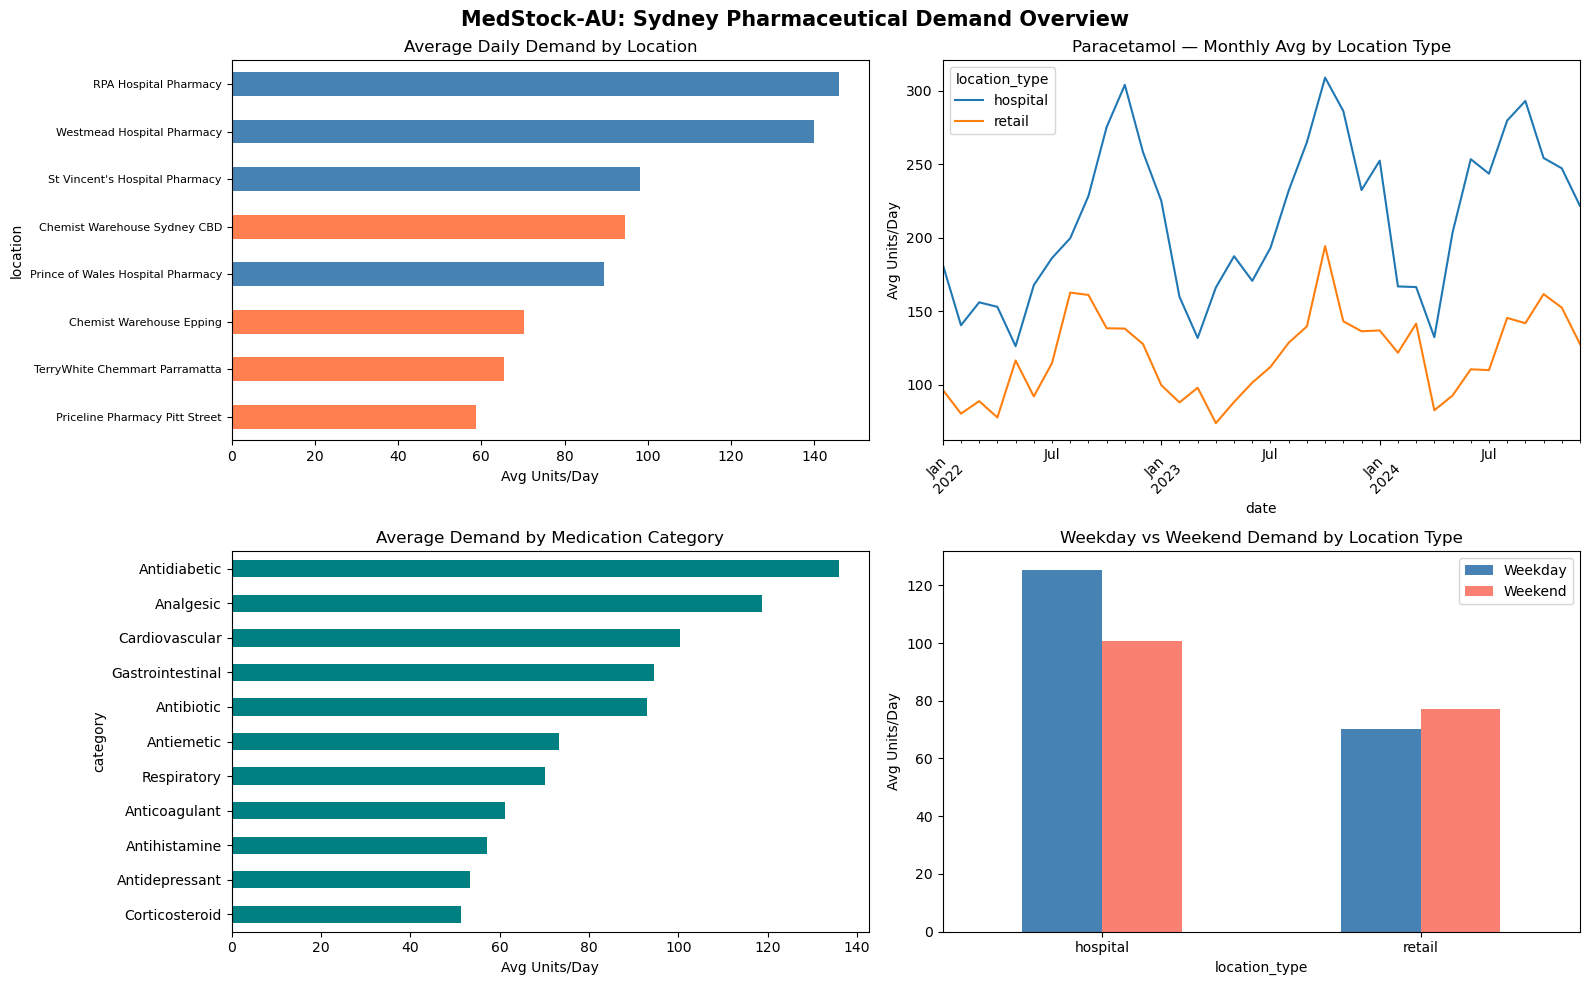

Chart saved to reports/


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('MedStock-AU: Sydney Pharmaceutical Demand Overview', fontsize=15, fontweight='bold')

# Plot 1: Average demand by location
ax1 = axes[0, 0]
loc_avg = df.groupby('location')['demand_units'].mean().sort_values()
colors  = ['steelblue' if 'Hospital' in x or 'RPA' in x or "St Vincent" in x or 'Prince' in x
           else 'coral' for x in loc_avg.index]
loc_avg.plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Average Daily Demand by Location')
ax1.set_xlabel('Avg Units/Day')
ax1.tick_params(axis='y', labelsize=8)

# Plot 2: Monthly demand — Paracetamol across all locations
ax2 = axes[0, 1]
para = df[df['medication'] == 'Paracetamol'].copy()
para_monthly = para.groupby([para['date'].dt.to_period('M'), 'location_type'])['demand_units'].mean().unstack()
para_monthly.index = para_monthly.index.to_timestamp()
para_monthly.plot(ax=ax2, linewidth=1.5)
ax2.set_title('Paracetamol — Monthly Avg by Location Type')
ax2.set_ylabel('Avg Units/Day')
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Demand by medication category
ax3 = axes[1, 0]
cat_avg = df.groupby('category')['demand_units'].mean().sort_values()
cat_avg.plot(kind='barh', ax=ax3, color='teal')
ax3.set_title('Average Demand by Medication Category')
ax3.set_xlabel('Avg Units/Day')

# Plot 4: Weekend vs Weekday by location type
ax4 = axes[1, 1]
weekend = df.groupby(['location_type', 'is_weekend'])['demand_units'].mean().unstack()
weekend.columns = ['Weekday', 'Weekend']
weekend.plot(kind='bar', ax=ax4, color=['steelblue', 'salmon'])
ax4.set_title('Weekday vs Weekend Demand by Location Type')
ax4.set_ylabel('Avg Units/Day')
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/01_demand_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

## 9. Save Dataset

In [11]:
output_path = '../data/raw/pharmacy_demand.csv'
df.to_csv(output_path, index=False)

print(f"Dataset saved  : {output_path}")
print(f"Total records  : {len(df):,}")
print(f"\nSample — RPA Hospital, Paracetamol:")
df[(df['location'] == 'RPA Hospital Pharmacy') &
   (df['medication'] == 'Paracetamol')].head(5)

Dataset saved  : ../data/raw/pharmacy_demand.csv
Total records  : 105,216

Sample — RPA Hospital, Paracetamol:


,date,location,location_type,suburb,medication,category,demand_units,is_weekend,month,quarter,day_of_week,day_of_year,year,reorder_point,unit_cost_aud,lead_time_days
0,2022-01-01,RPA Hospital Pharmacy,hospital,Camperdown,Paracetamol,Analgesic,199,1,1,1,5,1,2022,300,0.05,1
1,2022-01-02,RPA Hospital Pharmacy,hospital,Camperdown,Paracetamol,Analgesic,189,1,1,1,6,2,2022,300,0.05,2
2,2022-01-03,RPA Hospital Pharmacy,hospital,Camperdown,Paracetamol,Analgesic,249,0,1,1,0,3,2022,300,0.05,4
3,2022-01-04,RPA Hospital Pharmacy,hospital,Camperdown,Paracetamol,Analgesic,265,0,1,1,1,4,2022,300,0.05,3
4,2022-01-05,RPA Hospital Pharmacy,hospital,Camperdown,Paracetamol,Analgesic,231,0,1,1,2,5,2022,300,0.05,1
